## 1. Load final feature set
the hexagon grid with all 10 engineered predictors and the target variable

In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

gdf = gpd.read_file("../data/processed/berlin_h3_res8_with_all_features.geojson")

print(f"Shape: {gdf.shape}")
print(f"\nColumns:\n{gdf.columns.tolist()}")
gdf.head()

Shape: (1353, 14)

Columns:
['h3_index', 'resolution', 'popular_cafe_count', 'transit_stops_500m', 'rail_stations_800m', 'shops_500m', 'offices_500m', 'food_500m', 'universities_800m', 'coworking_500m', 'green_spaces_800m', 'culture_700m', 'population_density_per_km2', 'geometry']


,h3_index,resolution,popular_cafe_count,transit_stops_500m,rail_stations_800m,shops_500m,offices_500m,food_500m,universities_800m,coworking_500m,green_spaces_800m,culture_700m,population_density_per_km2,geometry
0,881f1886e5fffff,8,0,0,1,0,0,0,0,0,6,0,645.483719,"POLYGON ((13.18729 52.44134, 13.18509 52.43709..."
1,881f188445fffff,8,1,6,0,7,0,1,0,0,13,1,983.999349,"POLYGON ((13.13571 52.42082, 13.13351 52.41657..."
2,881f1d49edfffff,8,0,0,1,3,5,1,0,0,15,1,1237.594300,"POLYGON ((13.25213 52.48733, 13.24992 52.48308..."
3,881f18b363fffff,8,0,12,0,14,5,6,0,0,11,1,5090.690464,"POLYGON ((13.29944 52.43353, 13.29723 52.42928..."
4,881f1d40e5fffff,8,0,0,0,0,0,0,0,0,5,0,14.480433,"POLYGON ((13.438 52.64651, 13.43577 52.64228, ..."


## How zero-inflated is popular_cafe_count?
Expecting strong right-skew and a large number of zero-count hexagons similar to results in notebook 03.

count    1353.000000
mean        0.623799
std         2.012813
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        21.000000
Name: popular_cafe_count, dtype: float64

Hexagons with zero popular cafes: 1085 (80.2%)


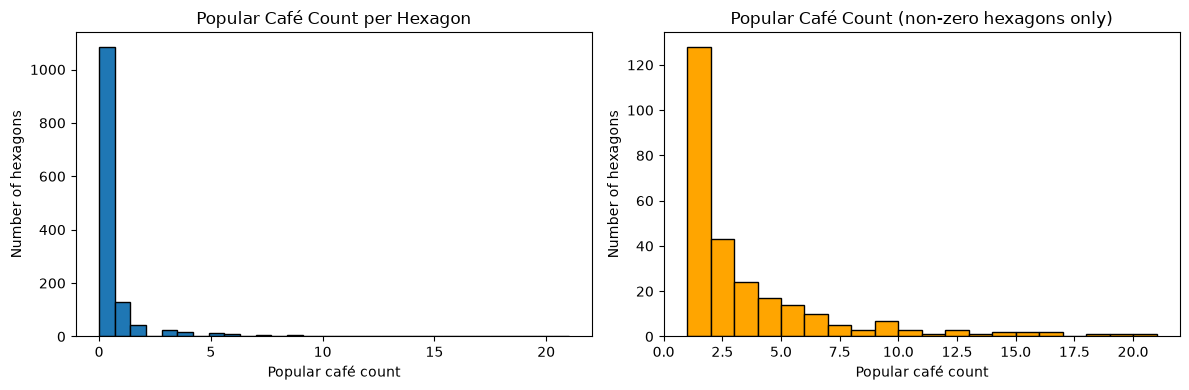

In [2]:
print(gdf['popular_cafe_count'].describe())

#zero popular cafes?
zero_count = (gdf['popular_cafe_count'] == 0).sum()
print(f"\nHexagons with zero popular cafes: {zero_count} ({zero_count/len(gdf)*100:.1f}%)")

# Histogram
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(gdf['popular_cafe_count'], bins=30, edgecolor='black')
axes[0].set_title('Popular Café Count per Hexagon')
axes[0].set_xlabel('Popular café count')
axes[0].set_ylabel('Number of hexagons')
axes[1].hist(gdf[gdf['popular_cafe_count'] > 0]['popular_cafe_count'], bins=20, edgecolor='black', color='orange')
axes[1].set_title('Popular Café Count (non-zero hexagons only)')
axes[1].set_xlabel('Popular café count')
axes[1].set_ylabel('Number of hexagons')

plt.tight_layout()
plt.show()

## Predictor distributions and missing-data check

Checking all 10 predictors for missing values and looking at how each one is distributed, before running correlation or VIF analysis on them.


Missing values per column:
transit_stops_500m            0
rail_stations_800m            0
shops_500m                    0
offices_500m                  0
food_500m                     0
universities_800m             0
coworking_500m                0
green_spaces_800m             0
culture_700m                  0
population_density_per_km2    0
dtype: int64

Summary statistics:


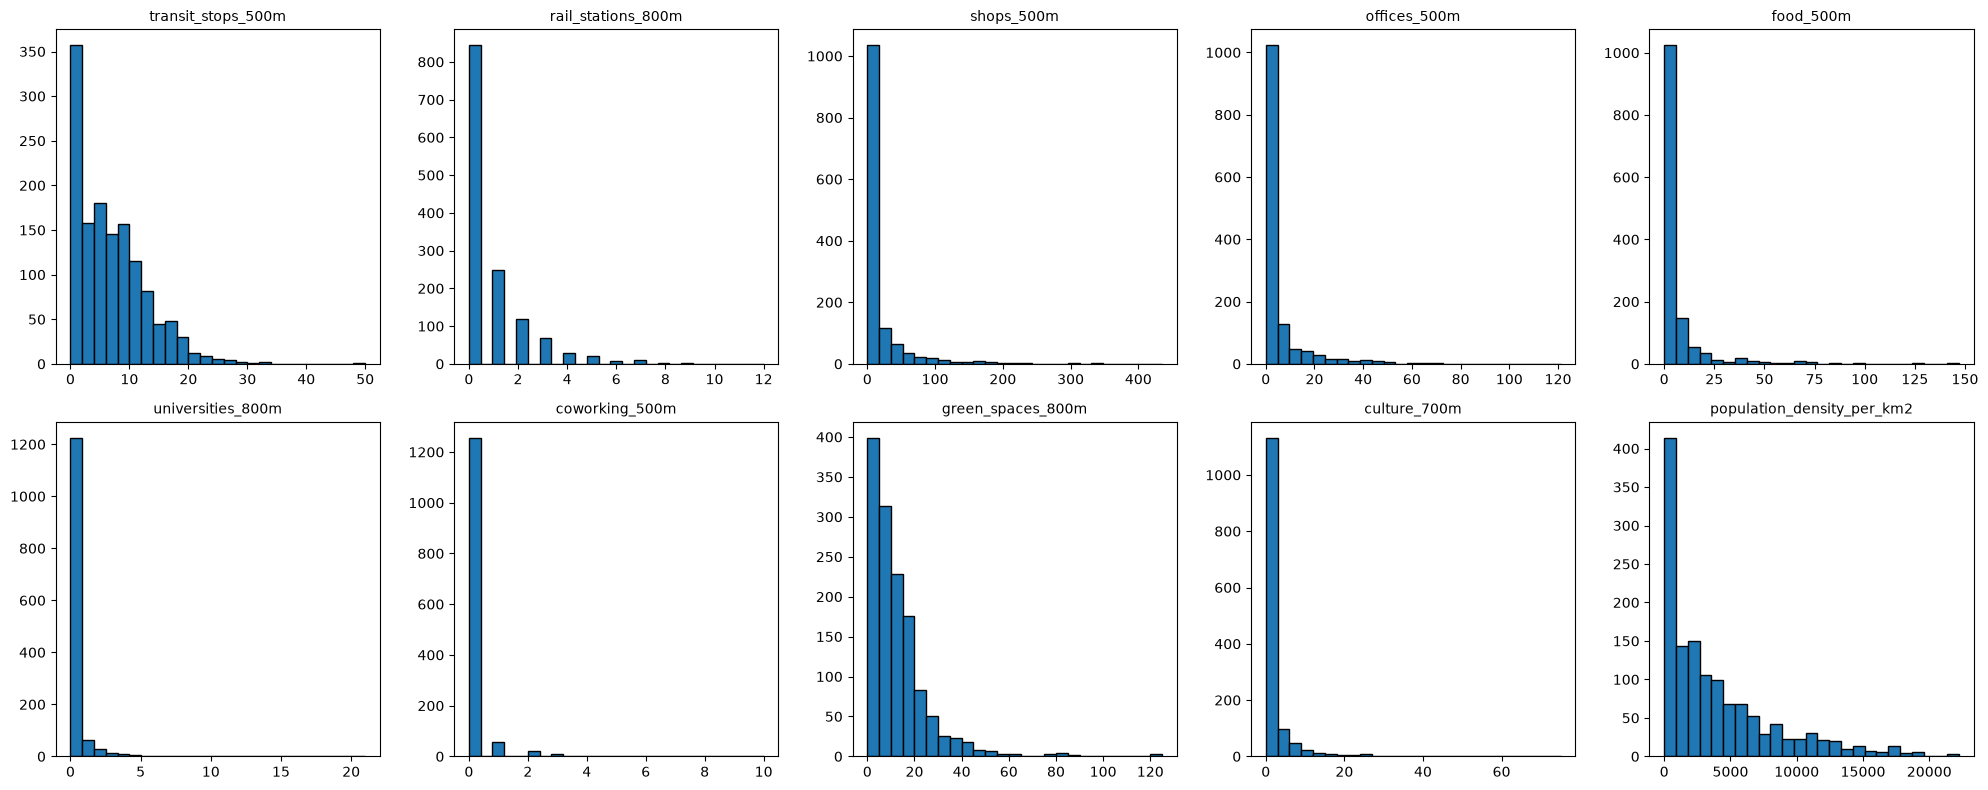

In [3]:
predictors = ['transit_stops_500m', 'rail_stations_800m', 'shops_500m', 
              'offices_500m', 'food_500m', 'universities_800m', 
              'coworking_500m', 'green_spaces_800m', 'culture_700m', 
              'population_density_per_km2']

print("Missing values per column:")
print(gdf[predictors].isnull().sum())

print("\nSummary statistics:")
gdf[predictors].describe().T

# Distributions
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(predictors):
    axes[i].hist(gdf[col], bins=25, edgecolor='black')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

## Correlation between the 10 predictors

Checking pairwise correlations between predictors.


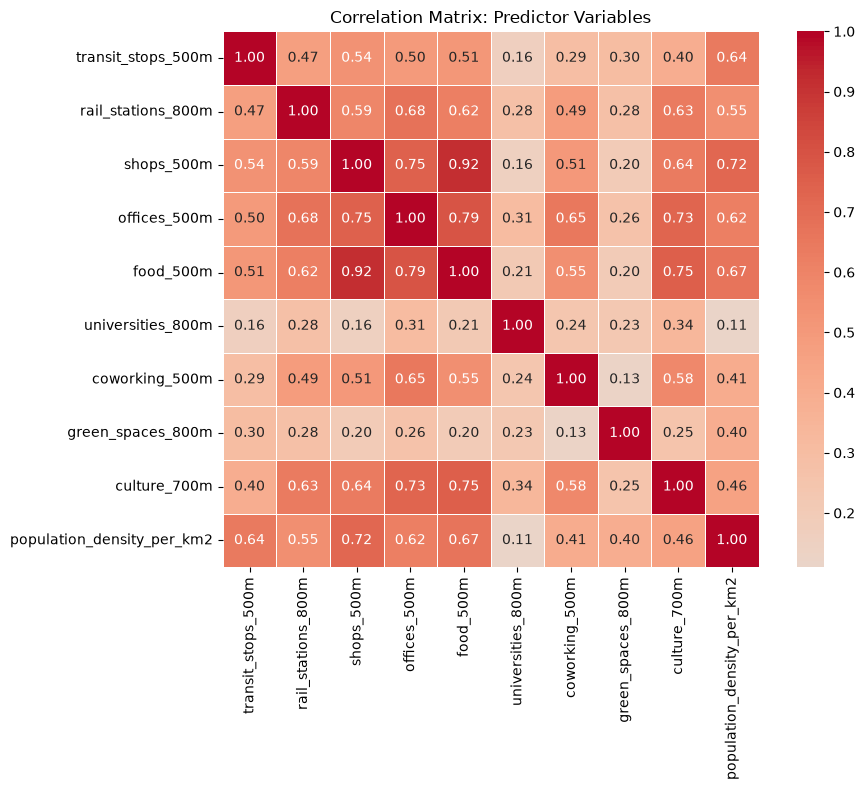

In [4]:
corr_matrix = gdf[predictors].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=0.5)
plt.title('Correlation Matrix: Predictor Variables')
plt.tight_layout()
plt.show()

## Multicollinearity check: Variance Inflation Factor

Checks multicollinearity across predictors following up on what the correlation matrix above hinted at.

In [5]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = sm.add_constant(gdf[predictors].copy())

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

vif_data = vif_data[vif_data["feature"] != "const"]
vif_data.sort_values("VIF", ascending=False)


,feature,VIF
5,food_500m,9.073302
3,shops_500m,7.361528
4,offices_500m,4.017438
9,culture_700m,3.171679
10,population_density_per_km2,3.025007
2,rail_stations_800m,2.167355
7,coworking_500m,1.849110
1,transit_stops_500m,1.809914
8,green_spaces_800m,1.309529
6,universities_800m,1.226006


## Predictor vs. popular_cafe_count relationships

A look at how each predictor relates to the target before the full XGBoost + SHAP analysis.

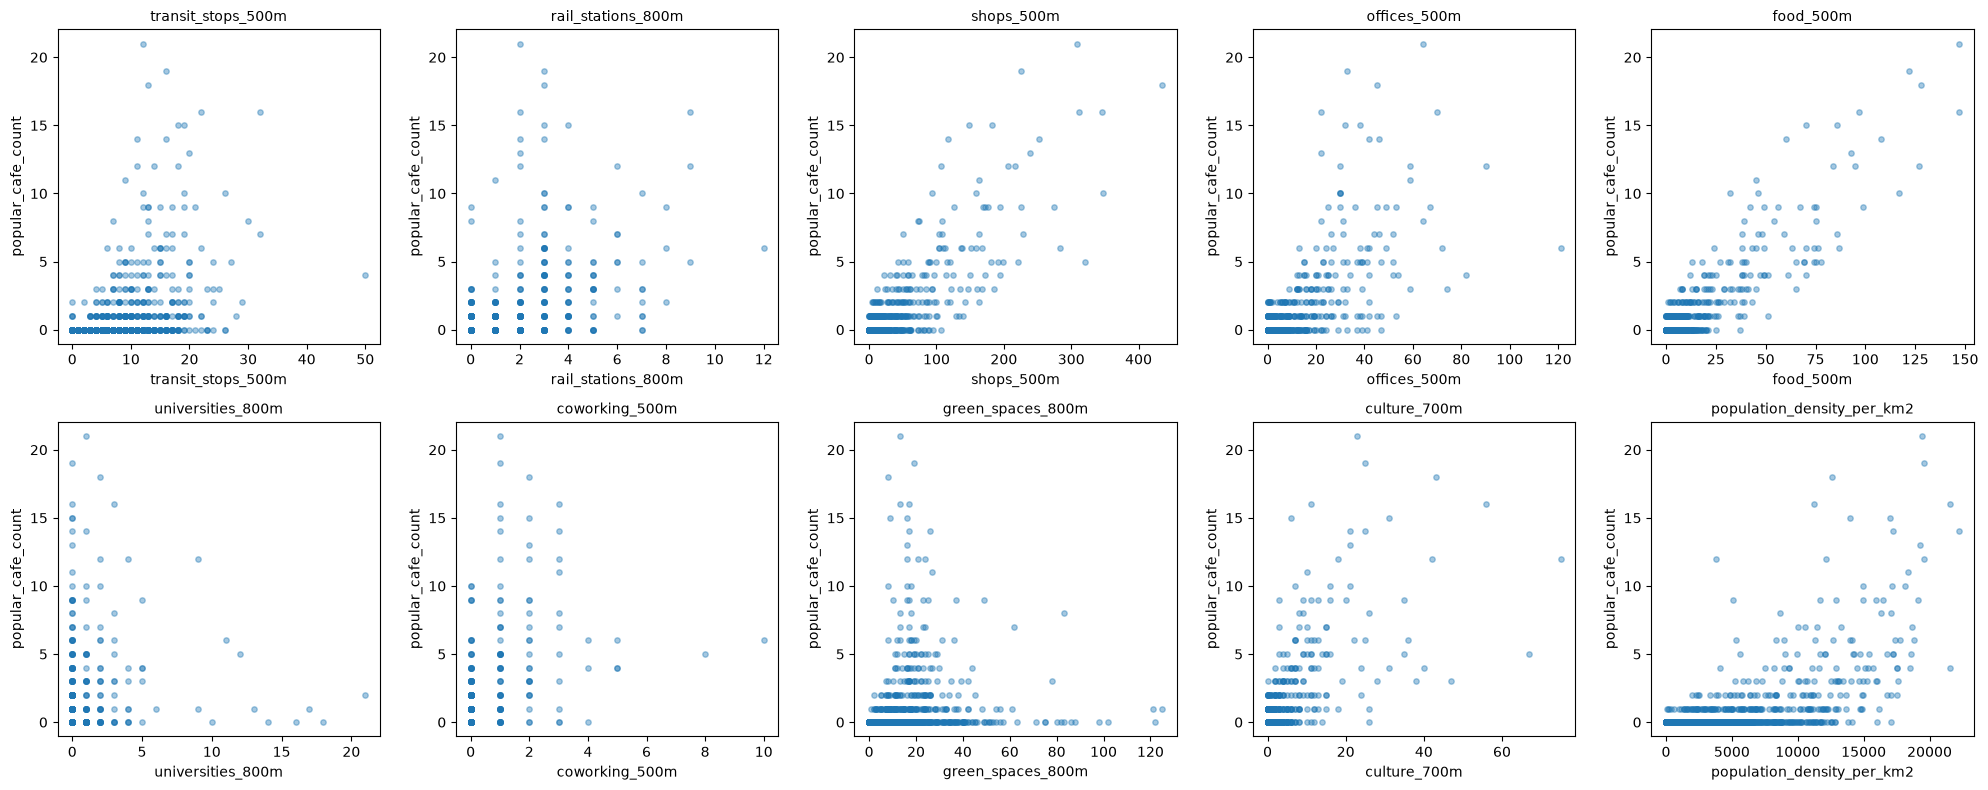

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(predictors):
    axes[i].scatter(gdf[col], gdf['popular_cafe_count'], alpha=0.4, s=15)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('popular_cafe_count')

plt.tight_layout()
plt.show()




Visual check that popular_cafe_count is distributed sensibly across Berlin before moving to modeling

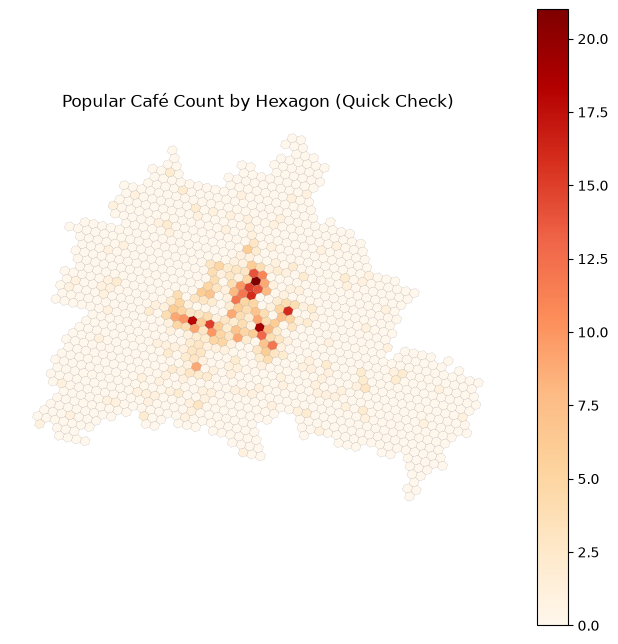

In [7]:
fig, ax = plt.subplots(figsize=(8, 8))
gdf.plot(column='popular_cafe_count', cmap='OrRd', legend=True, ax=ax, edgecolor='grey', linewidth=0.1)
ax.set_title('Popular Café Count by Hexagon (Quick Check)')
ax.set_axis_off()
plt.show()


## Testing for spatial clustering with Moran's I

Testing whether popular_cafe_count shows spatial clustering - neighbouring hexagons have similar values rather than random ones. First step is building a neighbour structure so the algorithm knows which hexagons are adjacent to each other.

In [8]:
from libpysal.weights import Queen

w = Queen.from_dataframe(gdf, use_index=False)
w.transform = 'r' 

print(f"Number of hexagons: {w.n}")
print(f"Average number of neighbors per hexagon: {w.mean_neighbors:.2f}")

Number of hexagons: 1353
Average number of neighbors per hexagon: 5.66


In [9]:
import numpy as np

x = gdf['popular_cafe_count'].values
x_bar = x.mean()
n = len(x)

S0 = w.sparse.sum()

W = w.sparse 
numerator = (x - x_bar) @ W @ (x - x_bar)


denominator = np.sum((x - x_bar) ** 2)

morans_i = (n / S0) * (numerator / denominator)
print(f"Moran's I: {morans_i:.4f}")

Moran's I: 0.6024


In [10]:
np.random.seed(42)

n_permutations = 999
simulated_morans = []

for _ in range(n_permutations):
    x_shuffled = np.random.permutation(x)
    x_shuffled_bar = x_shuffled.mean()
    
    numerator_sim = (x_shuffled - x_shuffled_bar) @ W @ (x_shuffled - x_shuffled_bar)
    denominator_sim = np.sum((x_shuffled - x_shuffled_bar) ** 2)
    
    morans_i_sim = (n / S0) * (numerator_sim / denominator_sim)
    simulated_morans.append(morans_i_sim)

simulated_morans = np.array(simulated_morans)

p_value = (np.sum(simulated_morans >= morans_i) + 1) / (n_permutations + 1)

print(f"Observed Moran's I: {morans_i:.4f}")
print(f"Mean of simulated (random) Moran's I: {simulated_morans.mean():.4f}")
print(f"P-value: {p_value:.4f}")

Observed Moran's I: 0.6024
Mean of simulated (random) Moran's I: -0.0012
P-value: 0.0010


## Summary of EDA findings

The target variable is zero-inflated - 80.2% of hexagons have no popular cafés, and the max is 21.This confirms overdispersion which is why a Poisson objective makes more sense here than standard regression.

None of the predictors have missing values. Most are right-skewed - universities, coworking, food,offices and culture all cluster in a small number of hexagons - while transit and green space are more evenly spread

shops_500m and food_500m are highly correlated (r = 0.92, VIF ). I'm keeping both, since XGBoost handles multicollinearity better than linear regression does

Looking at the scatterplots, shops, food, offices and population density show the clearest upward trend with café count. Green space looks weak or even slightly inverse, and universities/coworking don't show an obvious pattern - though this is only a single-variable view, so it could change once SHAP accounts for interactions between features.

The spatial map looks geographically sound, with café density clustering centrally and no signs ofmerge or geometry errors.

Moran's I came out at 0.60 (p = 0.001 over 999 permutations) - strong spatial clustering. This supports using spatial features to predict café density, and rules out treating
hexagons as independent observations.

data looks clean and ready